# PowerCo Churn - Exploratory Data Analysis
**Goal:** understand the data types and distributions of the client and price datasets before testing the price-sensitivity hypothesis (Step 2 of the BCG X methodology).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline
sns.set(color_codes=True)

## 1. Load data

In [4]:
client_df = pd.read_csv(r"C:\Users\Dell\Downloads\client_data (1).csv")
price_df = pd.read_csv(r"C:\Users\Dell\Downloads\price_data (1).csv")
print(client_df.shape, price_df.shape)
client_df.head(3)

(14606, 26) (193002, 8)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [5]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


## 2. Data types

In [6]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [7]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


**Observation:** no missing values in either file, but all `date_*` columns in `client_df` and `price_date` in `price_df` are stored as text. They should be converted to datetime. `has_gas` is `t`/`f` text (boolean), and `id`, `channel_sales`, `origin_up` are hashed categorical strings.

In [8]:
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for c in date_cols:
    client_df[c] = pd.to_datetime(client_df[c])
price_df['price_date'] = pd.to_datetime(price_df['price_date'])
client_df['has_gas'] = client_df['has_gas'].map({'t': 1, 'f': 0})
client_df[date_cols].dtypes

date_activ         datetime64[ns]
date_end           datetime64[ns]
date_modif_prod    datetime64[ns]
date_renewal       datetime64[ns]
dtype: object

## 3. Descriptive statistics

In [9]:
pd.set_option('display.width', 200)
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.0,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,2011-01-28 07:54:18.879912448,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018560,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663872,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279488,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531
forecast_cons_year,14606.0,1399.762906,0.0,0.0,314.0,1745.75,175375.0,3247.786255
forecast_discount_energy,14606.0,0.966726,0.0,0.0,0.0,0.0,30.0,5.108289


In [10]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


In [11]:
# Unique values per column and missing values
summary = pd.DataFrame({'unique': client_df.nunique(), 'missing': client_df.isna().sum()})
print(summary)
print('\nClients in client_df:', client_df['id'].nunique())
print('Clients in price_df :', price_df['id'].nunique())
print('Clients in price_df but not in client_df:', len(set(price_df['id']) - set(client_df['id'])))
print('Price dates:', sorted(price_df['price_date'].dt.strftime('%Y-%m').unique()))

                                unique  missing
id                               14606        0
channel_sales                        8        0
cons_12m                         11065        0
cons_gas_12m                      2112        0
cons_last_month                   4751        0
date_activ                        1796        0
date_end                           368        0
date_modif_prod                   2129        0
date_renewal                       386        0
forecast_cons_12m                13993        0
forecast_cons_year                4218        0
forecast_discount_energy            12        0
forecast_meter_rent_12m           3528        0
forecast_price_energy_off_peak     516        0
forecast_price_energy_peak         329        0
forecast_price_pow_off_peak         41        0
has_gas                              2        0
imp_cons                          7752        0
margin_gross_pow_ele              2391        0
margin_net_pow_ele                2391  

In [12]:
# Categorical columns
for c in ['channel_sales', 'origin_up']:
    print(client_df[c].value_counts(), '\n')

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64 

origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64 



In [13]:
# Zeros and skewness in numeric columns
num = client_df.select_dtypes('number').drop(columns=['churn', 'has_gas'])
pd.DataFrame({'pct_zero': (num == 0).mean() * 100, 'skew': num.skew()}).round(2).sort_values('skew', ascending=False)

,pct_zero,skew
net_margin,1.27,36.57
forecast_cons_year,42.09,16.59
imp_cons,42.24,13.20
cons_gas_12m,82.12,9.60
nb_prod_act,0.00,8.64
forecast_cons_12m,2.10,7.16
cons_last_month,34.12,6.39
cons_12m,0.80,6.00
pow_max,0.00,5.79
forecast_discount_energy,96.49,5.16


**Observations**
- Consumption columns (`cons_12m`, `cons_gas_12m`, `cons_last_month`, `imp_cons`) and margins are **highly right-skewed**: the mean is far above the median and the max is orders of magnitude bigger than the 75th percentile. A few very large customers (or outliers) dominate.
- `cons_gas_12m` is 0 for most clients, as most are not gas clients.
- `margin_gross_pow_ele` and `margin_net_pow_ele` are almost identical.
- `price_df` has more unique clients than `client_df`, so the two files must be joined carefully. Several price columns (`price_peak_*`, `price_mid_peak_*`) are 0 for many rows, meaning those price periods do not apply to every client.
- `channel_sales` has a large `MISSING` category, which is an explicit missing-value marker.

## 4. Visualisation
Helper functions from the starter notebook.

In [14]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    ax = dataframe.plot(kind="bar", stacked=True, figsize=size_, rot=rot_, title=title_)
    annotate_stacked_bars(ax, textsize=14)
    plt.legend(["Retention", "Churn"], loc=legend_)
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    for p in ax.patches:
        value = str(round(p.get_height(), 1))
        if value == '0.0':
            continue
        ax.annotate(value, ((p.get_x() + p.get_width() / 2) * pad - 0.05, (p.get_y() + p.get_height() / 2) * pad),
                    color=colour, size=textsize)

def plot_distribution(dataframe, column, ax, bins_=50):
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"] == 0][column],
                         "Churn": dataframe[dataframe["churn"] == 1][column]})
    temp[["Retention", "Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    ax.set_xlabel(column)
    ax.ticklabel_format(style='plain', axis='x')

### 4.1 Churn rate

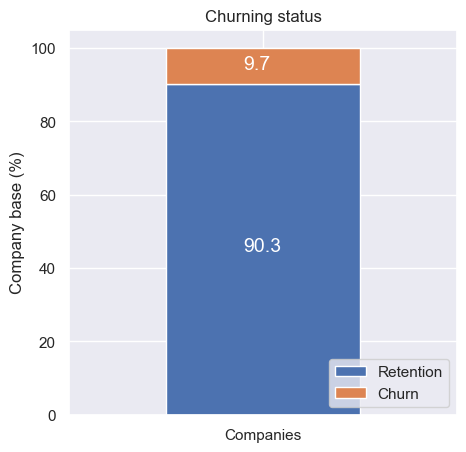

In [15]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), 'Churning status', (5, 5), legend_='lower right')

About **9.7%** of clients churned, so the target is imbalanced. This matters for modelling later (accuracy alone would be misleading).

### 4.2 Consumption distributions

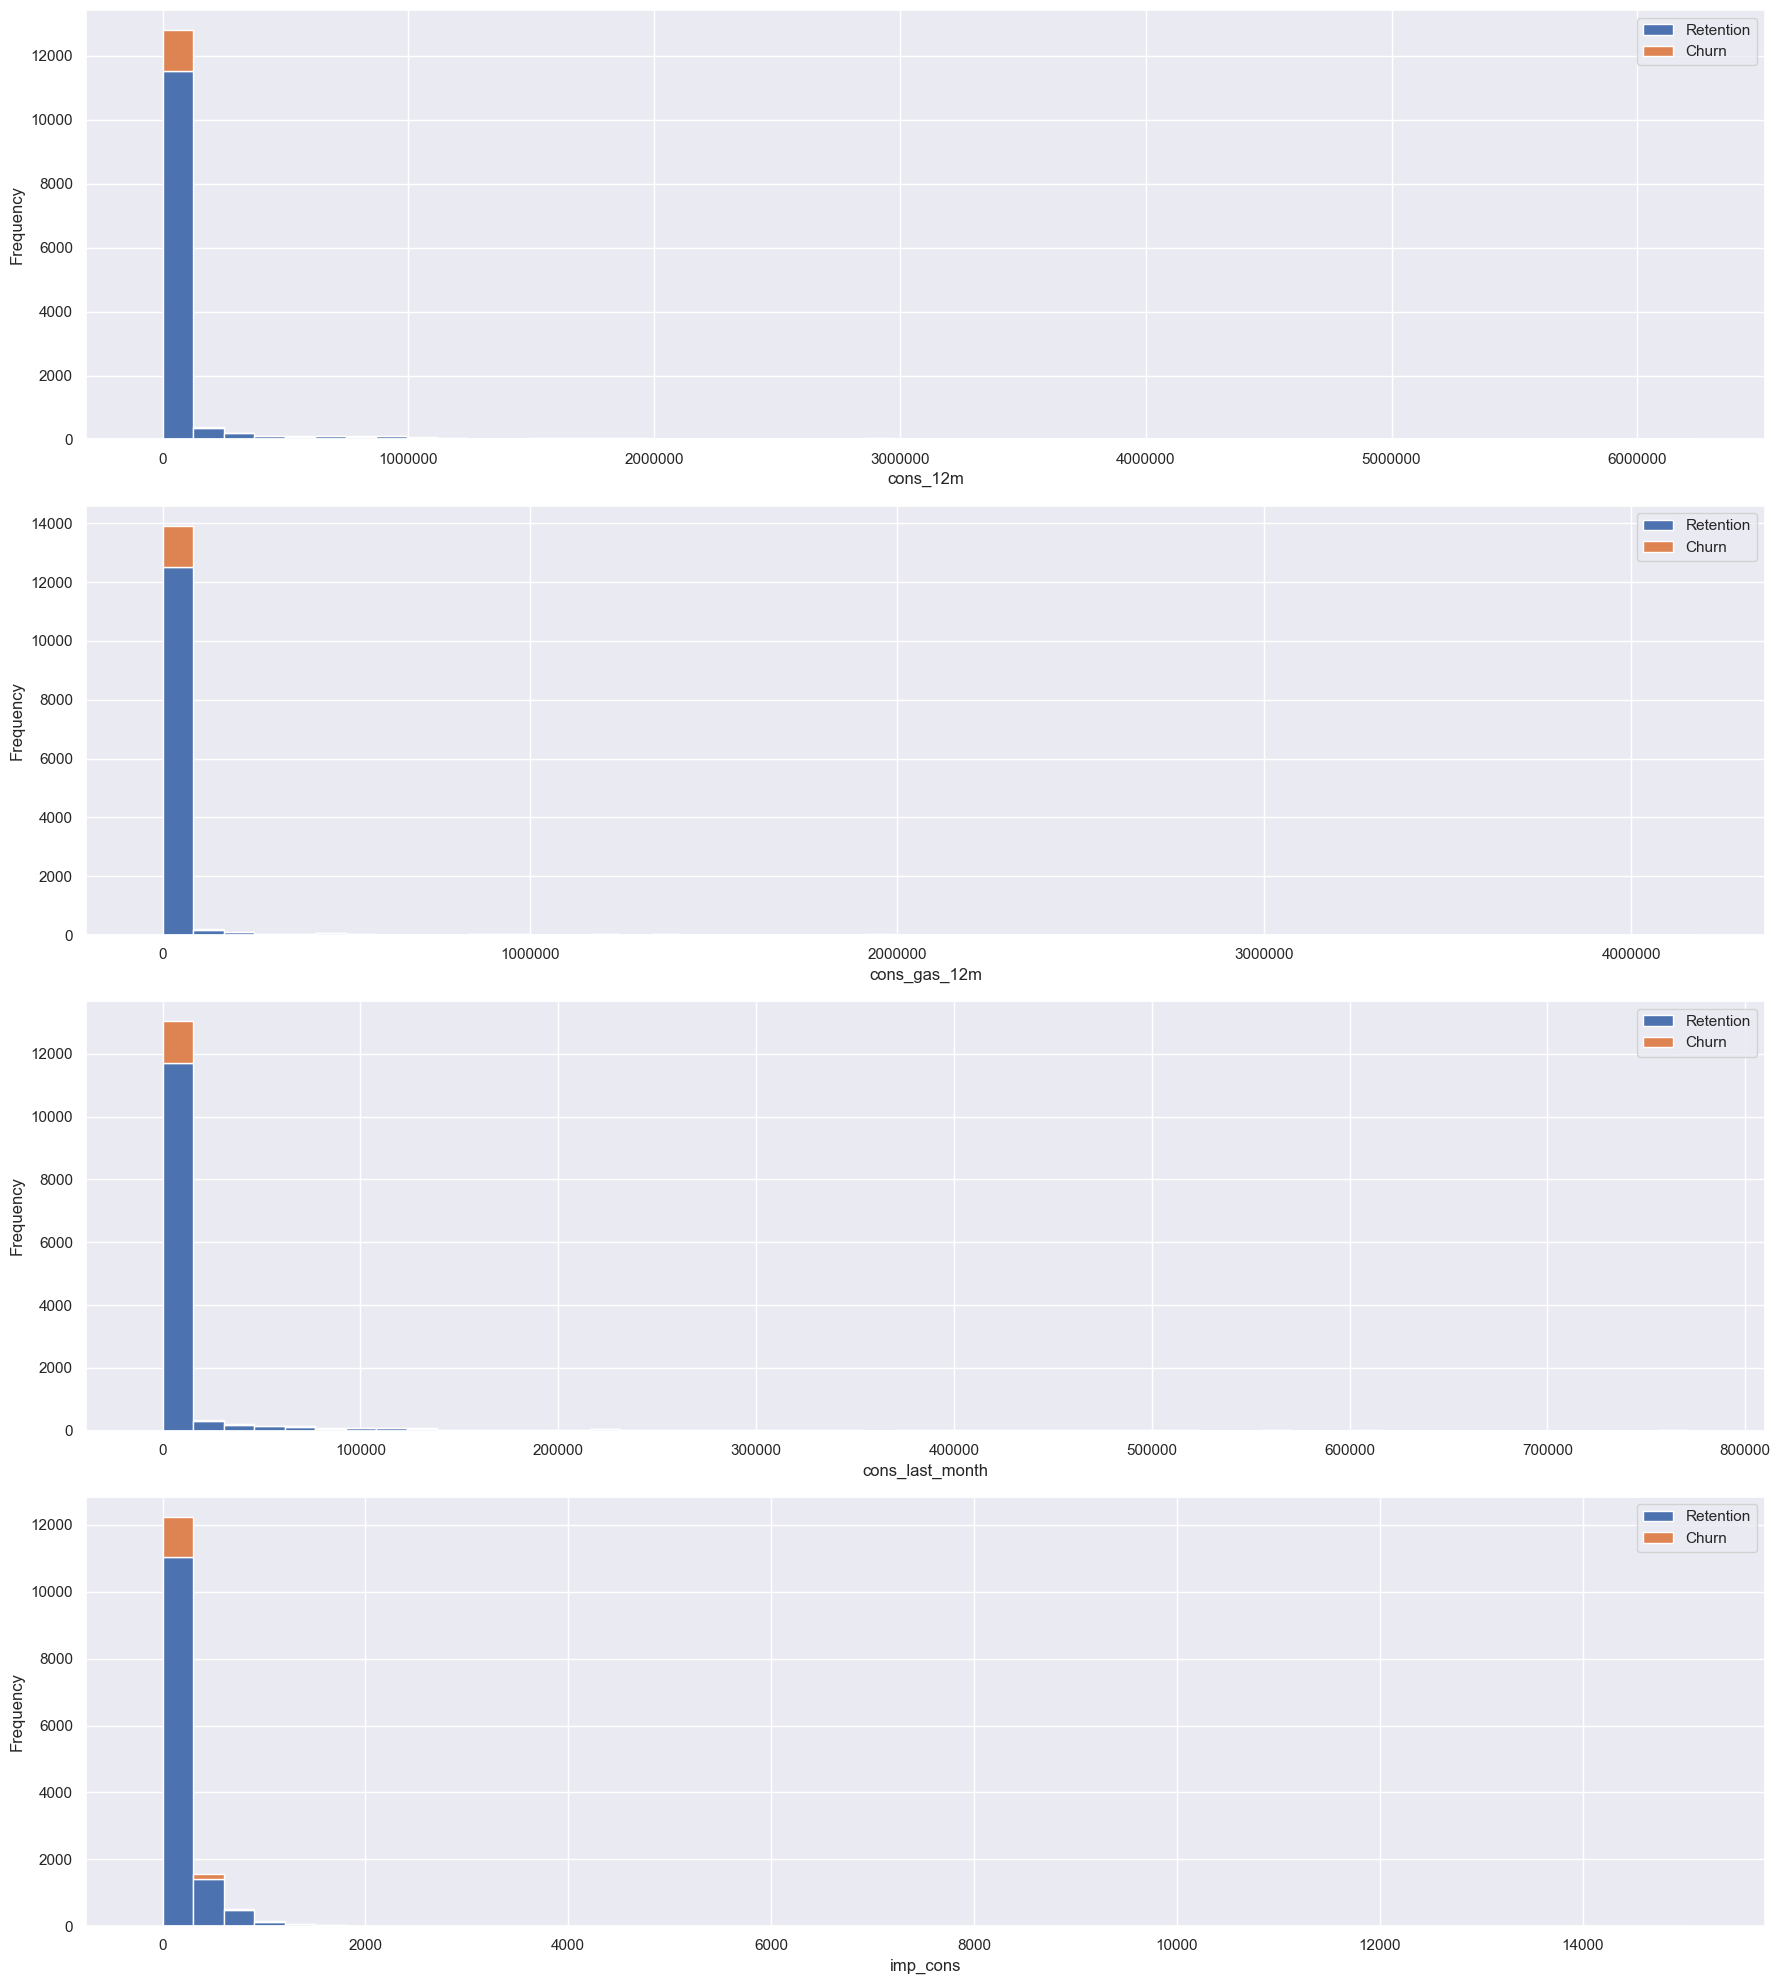

In [16]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]
fig, axs = plt.subplots(nrows=4, figsize=(18, 20))
for ax, col in zip(axs, ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons']):
    plot_distribution(consumption, col, ax)
plt.tight_layout()

All four are heavily right-skewed with a long tail, so the histograms are squeezed against zero. Log-scaling or outlier handling will be needed in the next steps.

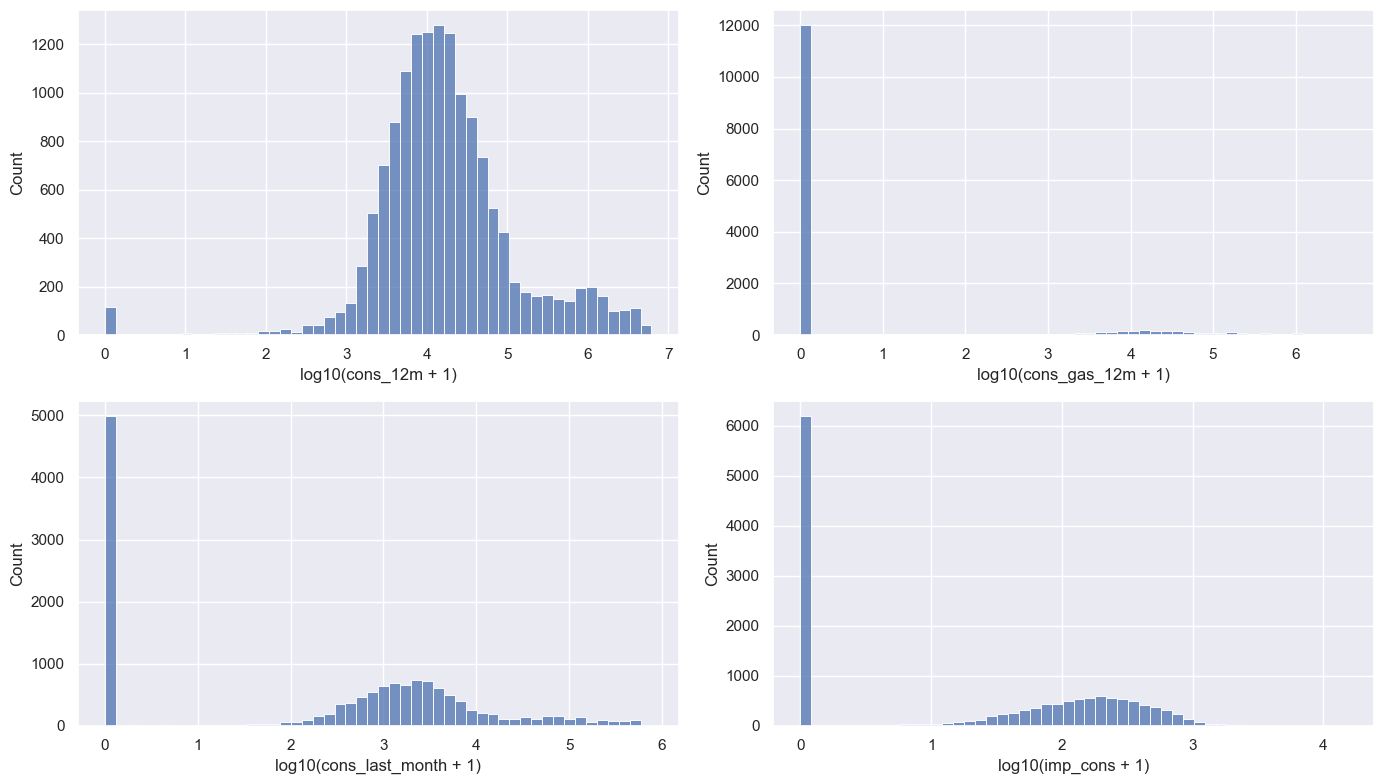

In [17]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
for ax, col in zip(axs.ravel(), ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons']):
    sns.histplot(np.log10(client_df[col] + 1), bins=50, ax=ax)
    ax.set_xlabel('log10(' + col + ' + 1)')
plt.tight_layout()

After a log transform the shapes are much easier to read. Note the spike at 0 (clients with no gas / no consumption).

### 4.3 Forecast and power/margin variables

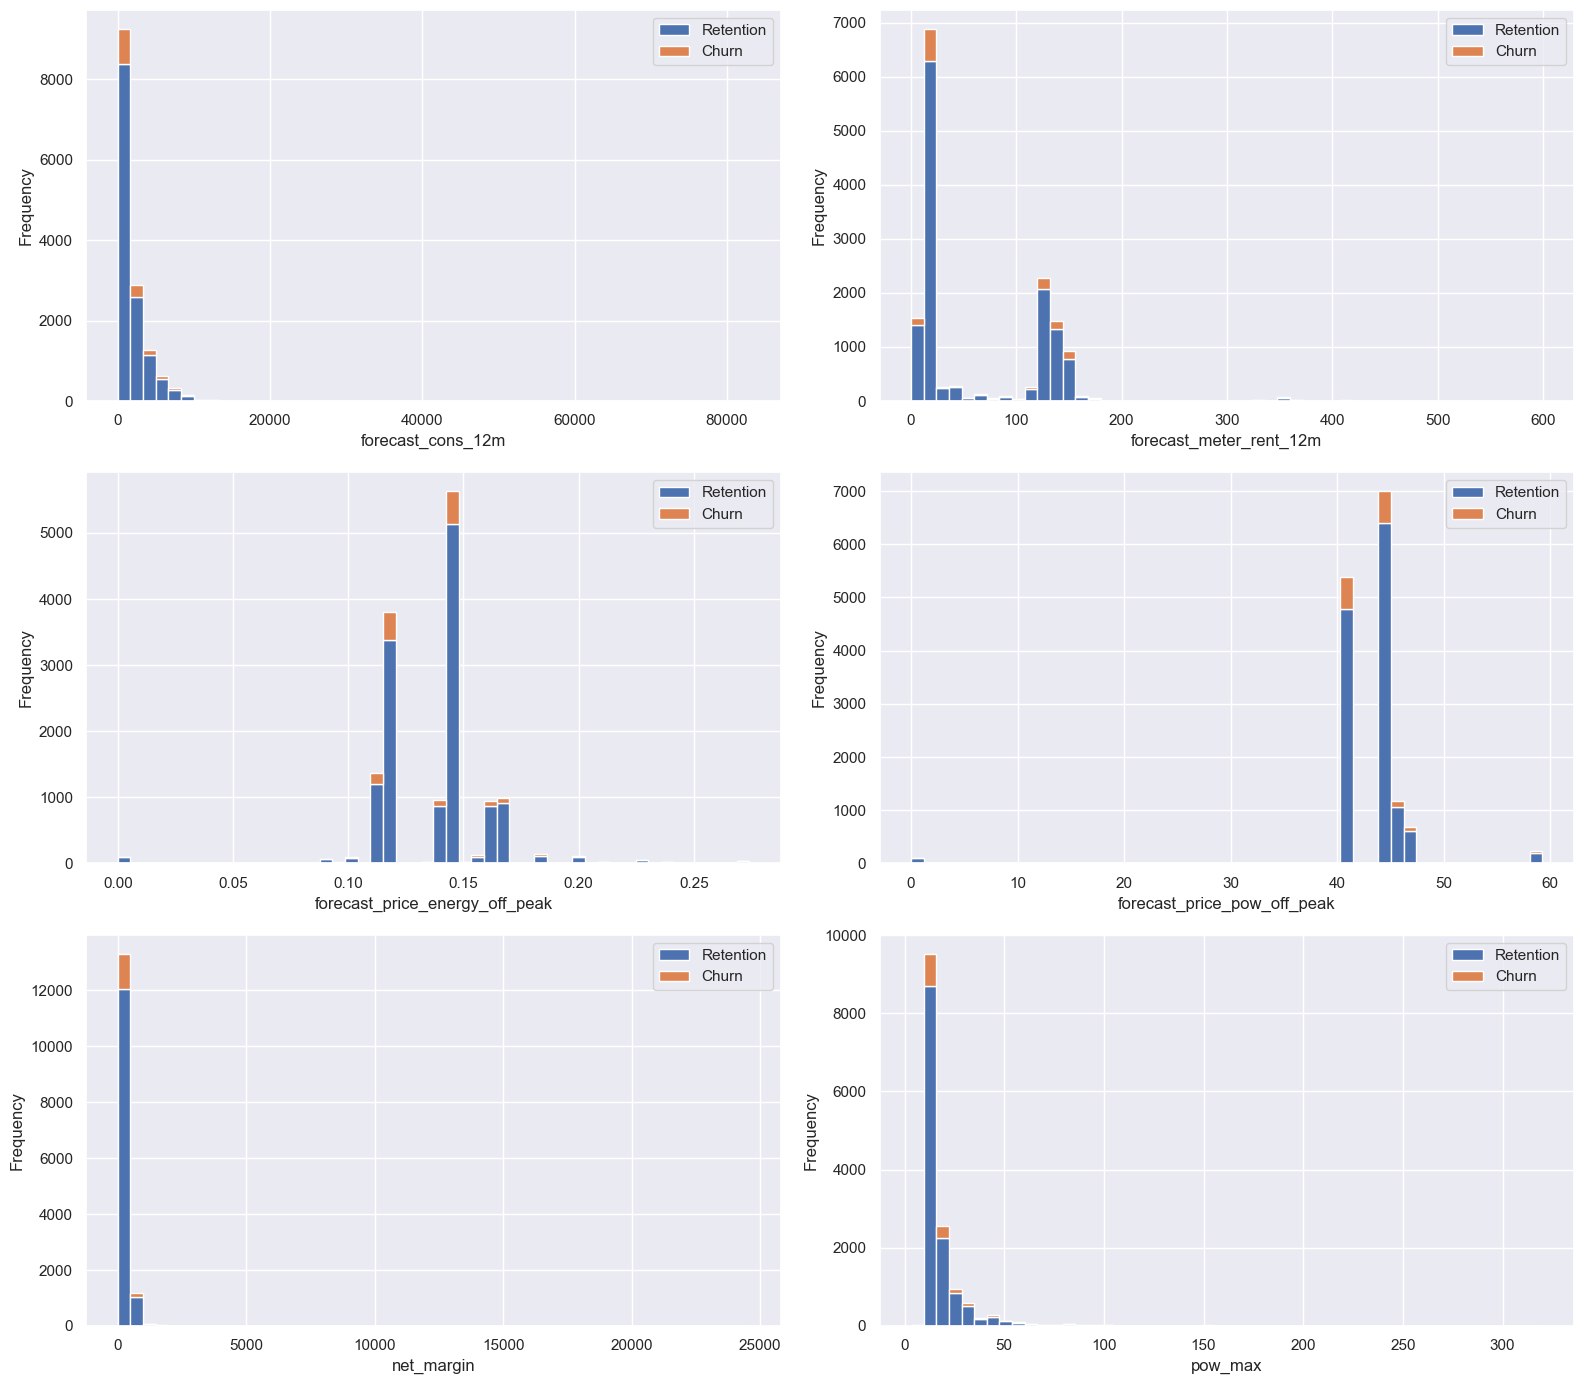

In [18]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
for ax, col in zip(axs.ravel(), ['forecast_cons_12m', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_pow_off_peak', 'net_margin', 'pow_max']):
    plot_distribution(client_df, col, ax)
plt.tight_layout()

### 4.4 Categorical variables and churn

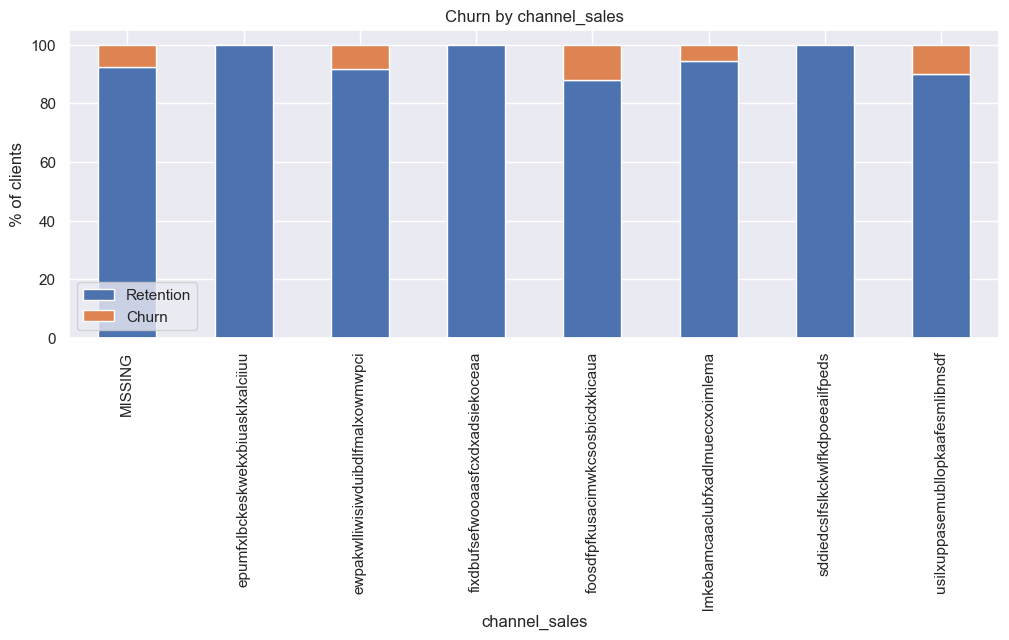

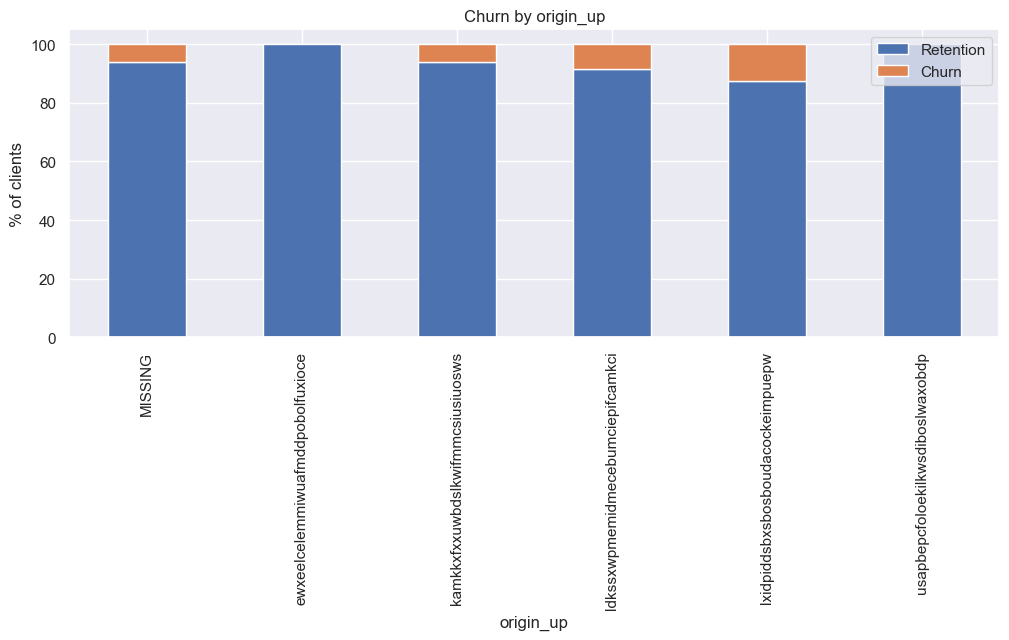

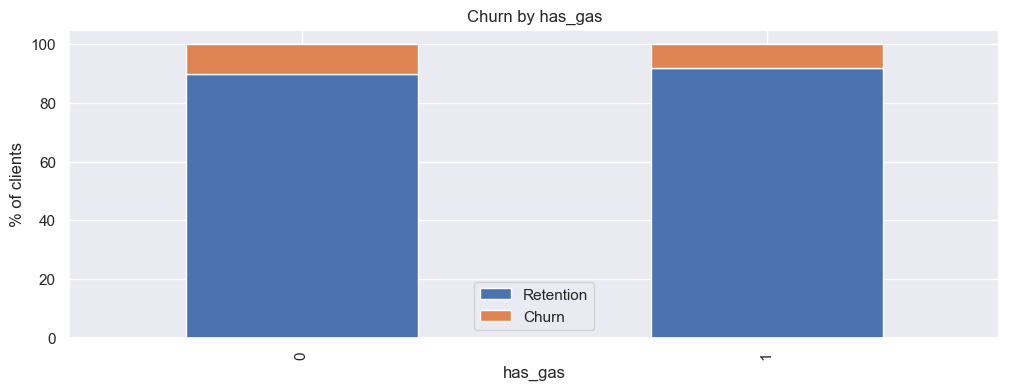

In [20]:
def churn_by(col):
    t = client_df.groupby([col, 'churn']).size().unstack(fill_value=0)
    return t.div(t.sum(axis=1), axis=0) * 100

for col in ['channel_sales', 'origin_up', 'has_gas']:
    pct = churn_by(col)
    pct.plot(kind='bar', stacked=True, figsize=(12, 4), title='Churn by ' + col)
    plt.ylabel('% of clients')
    plt.legend(['Retention', 'Churn'])
    plt.show()

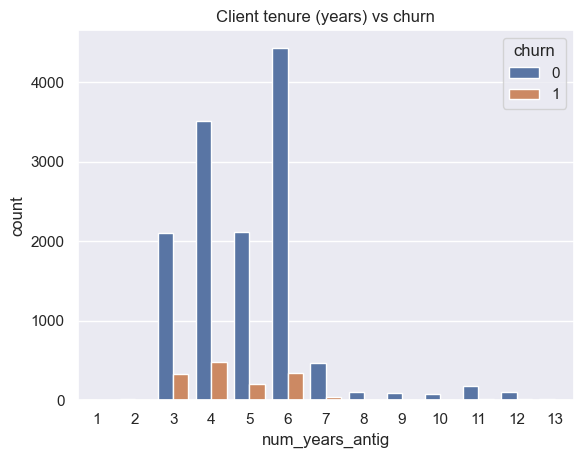

In [21]:
sns.countplot(x='num_years_antig', hue='churn', data=client_df)
plt.title('Client tenure (years) vs churn')
plt.show()

### 4.5 Price data

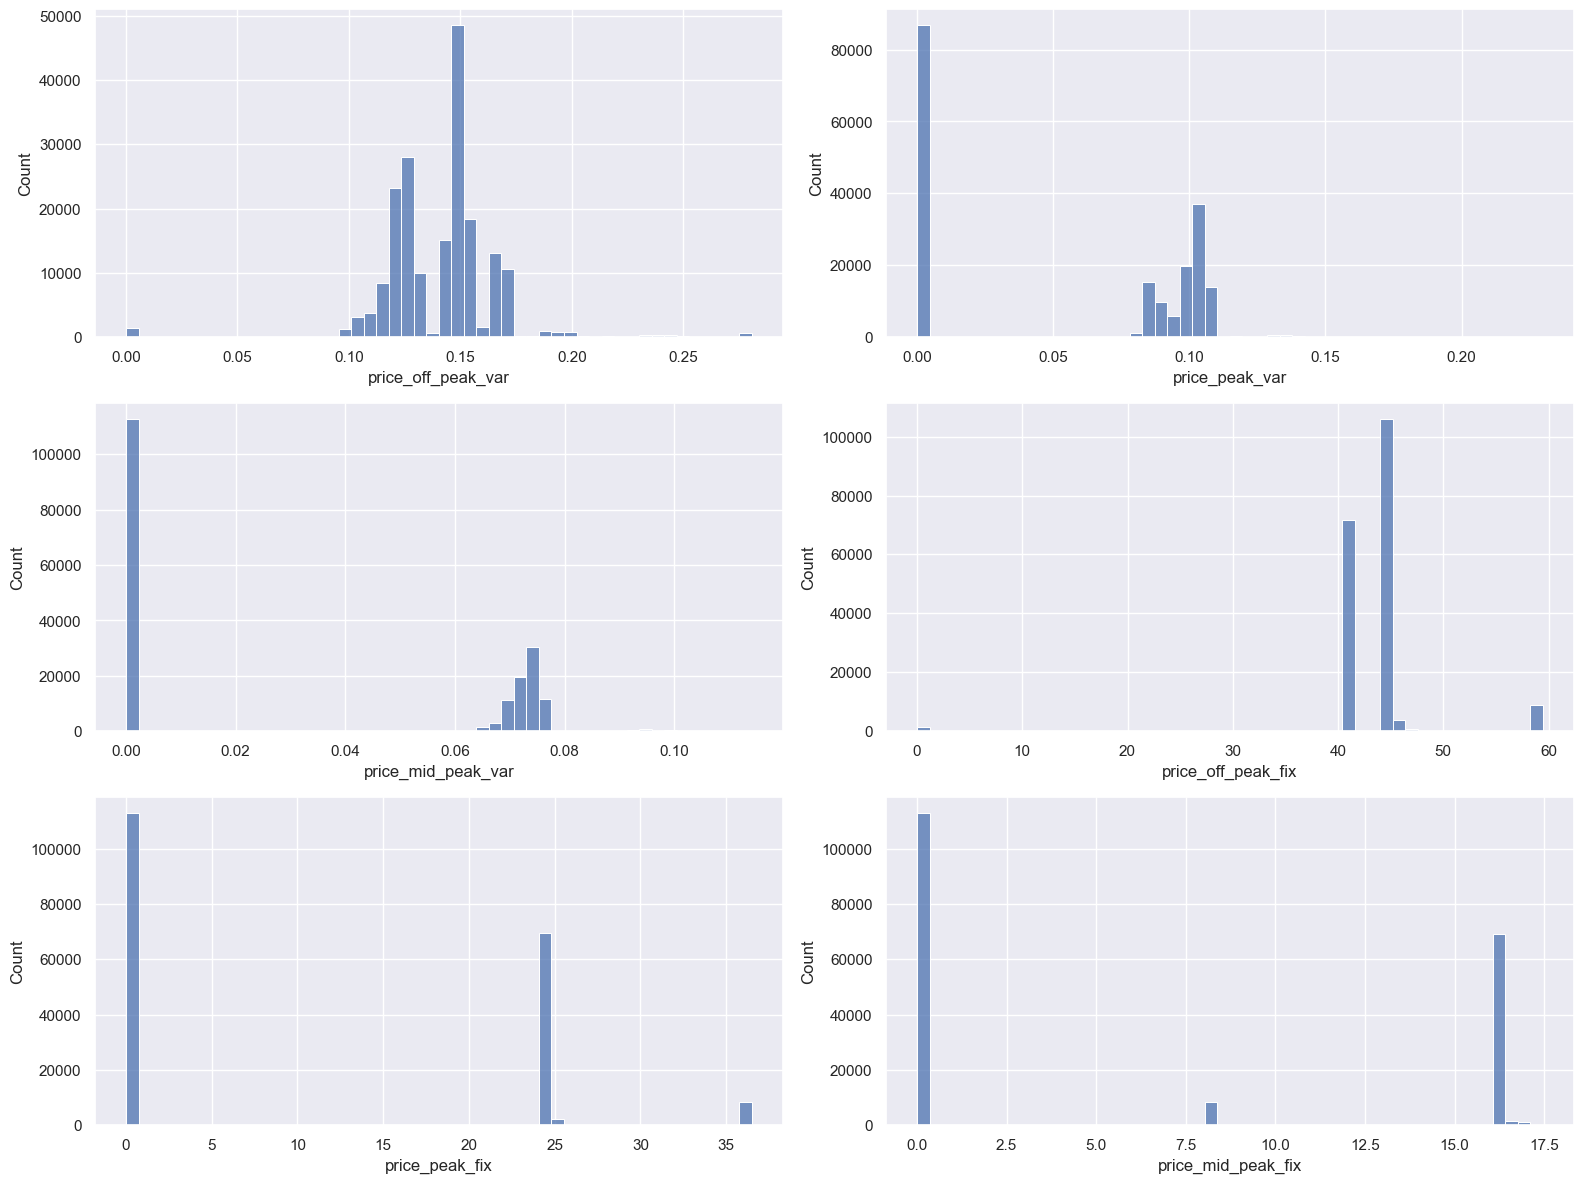

In [22]:
price_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
for ax, col in zip(axs.ravel(), price_cols):
    sns.histplot(price_df[col], bins=50, ax=ax)
plt.tight_layout()

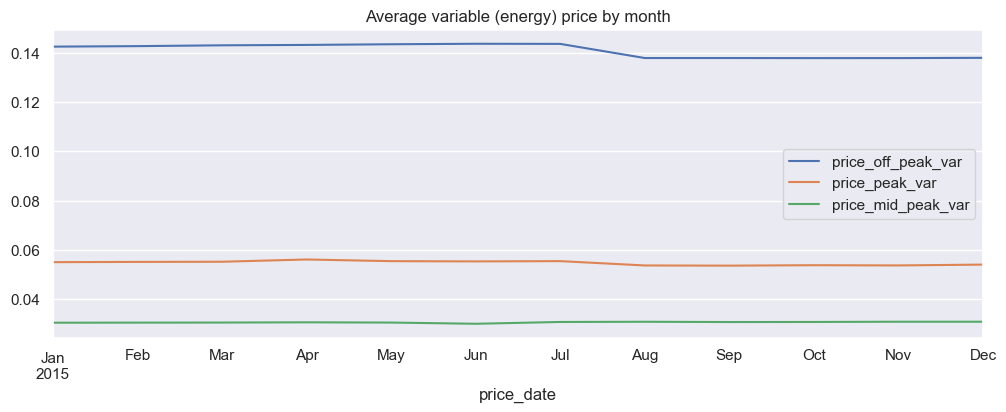

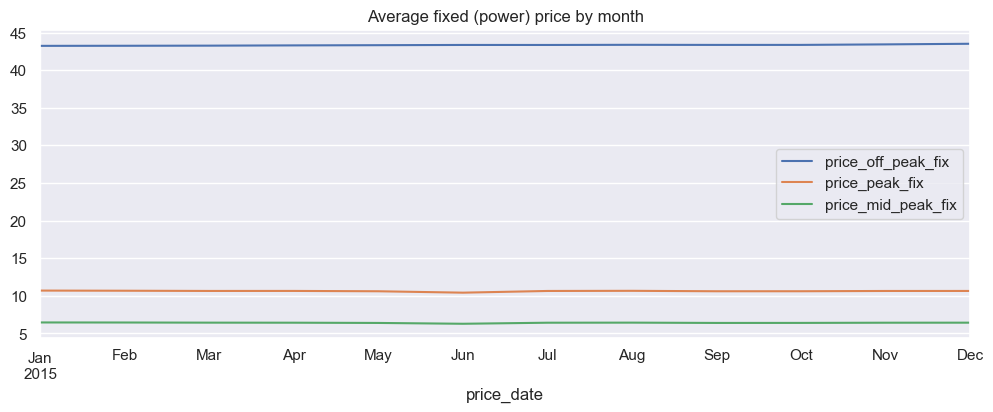

In [23]:
monthly = price_df.groupby('price_date')[price_cols].mean()
monthly[price_cols[:3]].plot(figsize=(12, 4), title='Average variable (energy) price by month')
monthly[price_cols[3:]].plot(figsize=(12, 4), title='Average fixed (power) price by month')
plt.show()

## 5. Summary of findings
1. **Data types:** dates are strings and need conversion to datetime; `has_gas` should be boolean; `id`, `channel_sales`, `origin_up` are hashed categoricals. No nulls, but `channel_sales` uses a `MISSING` label.
2. **Distributions:** consumption, forecast and margin variables are strongly right-skewed with outliers and many zeros, so transformations (log) or outlier treatment are needed before modelling.
3. **Target:** ~9.7% churn, an imbalanced target.
4. **Price data:** 12 monthly snapshots for 2015; it contains more client ids than the client file, so a merge must be checked. Many peak/mid-peak prices are 0, which reflects tariff structure rather than a true zero price.
5. **Next step (feature engineering):** compute price changes over time per client (for example Dec vs Jan, or last 6 months vs first 6 months), and join them to the churn flag to test the price-sensitivity hypothesis.

*Note:* `activity_new` is listed in the data description but is not present in `client_data.csv`.